# Notebook 3 : Network Topology Evolution and TERGM Analysis

This notebook has two parts.

**Part A (Sections 3.1 to 3.3):** Documents how the intra euro area production network structure evolved from 1995 to 2022.

**Part B (Sections 3.4 to 3.7):** Estimates a Temporal Exponential Random Graph Model (TERGM) on the **full sector level network (817 nodes)** to test whether ECB monetary policy shocks predict changes in the production network structure. This addresses the reverse causality question: does monetary policy *change* the network, or is the network a fixed structural feature that shapes how policy transmits?

**Key result:** The TERGM confirms that supply chain links persist with overwhelming strength (memory coefficient 4.51, implying 91x persistence) and that ECB rate changes have zero detectable effect on link formation or dissolution. This establishes that the network is exogenous to monetary policy, supporting the causal interpretation of the transmission regression in Notebook 4.

**Runtime:** The sector level TERGM (817 x 817 adjacency matrices, 28 years, 100 bootstrap replications) completed in approximately 2 hours.

**Requirements:** Run Notebook 1 first. R with `btergm` for the TERGM. A Python fallback runs if R is unavailable.

This cell loads all required libraries, sets up file paths, and checks whether R is installed. The TERGM estimation requires R with the `btergm` package. If R is not available, the notebook falls back to Python based network change regressions in Section 3.6.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

from network_metrics import (
    load_metrics_panel, compute_country_level_topology,
    compute_eigenvector_centrality, compute_network_change,
    compute_structural_break_panel, detect_production_clusters,
)
from tiva_loader import EA_COUNTRIES_TIVA, build_network_panel_from_tiva2025, load_tiva_2025

DATA_PROC = Path('../data/processed')
DATA_RAW_TIVA = Path('../data/raw/tiva')
RESULTS   = Path('../results/figures')
TABLES    = Path('../results/tables')
for p in [RESULTS, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

import subprocess
try:
    result = subprocess.run(['Rscript', '--version'],
                            capture_output=True, text=True, timeout=10)
    HAS_R = result.returncode == 0
except Exception:
    HAS_R = False

print(f'R available: {HAS_R}')
if not HAS_R:
    print('TERGM requires R with btergm. Section 3.6 provides a Python fallback.')

R available: True


---
## 3.1 Load Network Panel

Load the cached metrics panel and country topology from Notebook 1. The metrics panel provides sector level forward linkage, upstreamness, and community assignments for all 817 nodes across 28 years. The country topology provides the NCI and other aggregated measures used as covariates.

In [2]:
metrics_path = DATA_PROC / 'network_metrics_panel.parquet'
topo_path    = DATA_PROC / 'country_topology.parquet'

if not metrics_path.exists():
    raise FileNotFoundError('Run Notebook 1 first.')

metrics = load_metrics_panel(DATA_PROC)
topo    = pd.read_parquet(topo_path)

print(f'Metrics panel: {len(metrics):,} obs')
print(f'Years: {metrics.reset_index()["year"].min()} to '
      f'{metrics.reset_index()["year"].max()}')
print(f'Countries: {metrics.reset_index()["country"].nunique()}')
print(f'Sectors per country: '
      f'{metrics.reset_index().groupby("country")["sector"].nunique().mean():.1f}')

Metrics panel: 22,876 obs
Years: 1995 to 2022
Countries: 19
Sectors per country: 43.0


### Results

The panel contains 22,876 country sector year observations: 19 countries, 43 sectors per country, 28 years (1995 to 2022). These are the same metrics computed in Notebook 1. The topology panel adds country level summaries including NCI (Gini of sector forward linkage), centrality HHI, and mean upstreamness.

---
## 3.2 Network Structure Over Time

Four panels tracking the evolution of the EA production network from 1995 to 2022. Vertical lines mark three potential structural breaks: the 2009 financial crisis, the 2020 pandemic, and the 2022 energy and geopolitical shock. If the network were responsive to macroeconomic shocks, we would expect visible discontinuities at these dates.

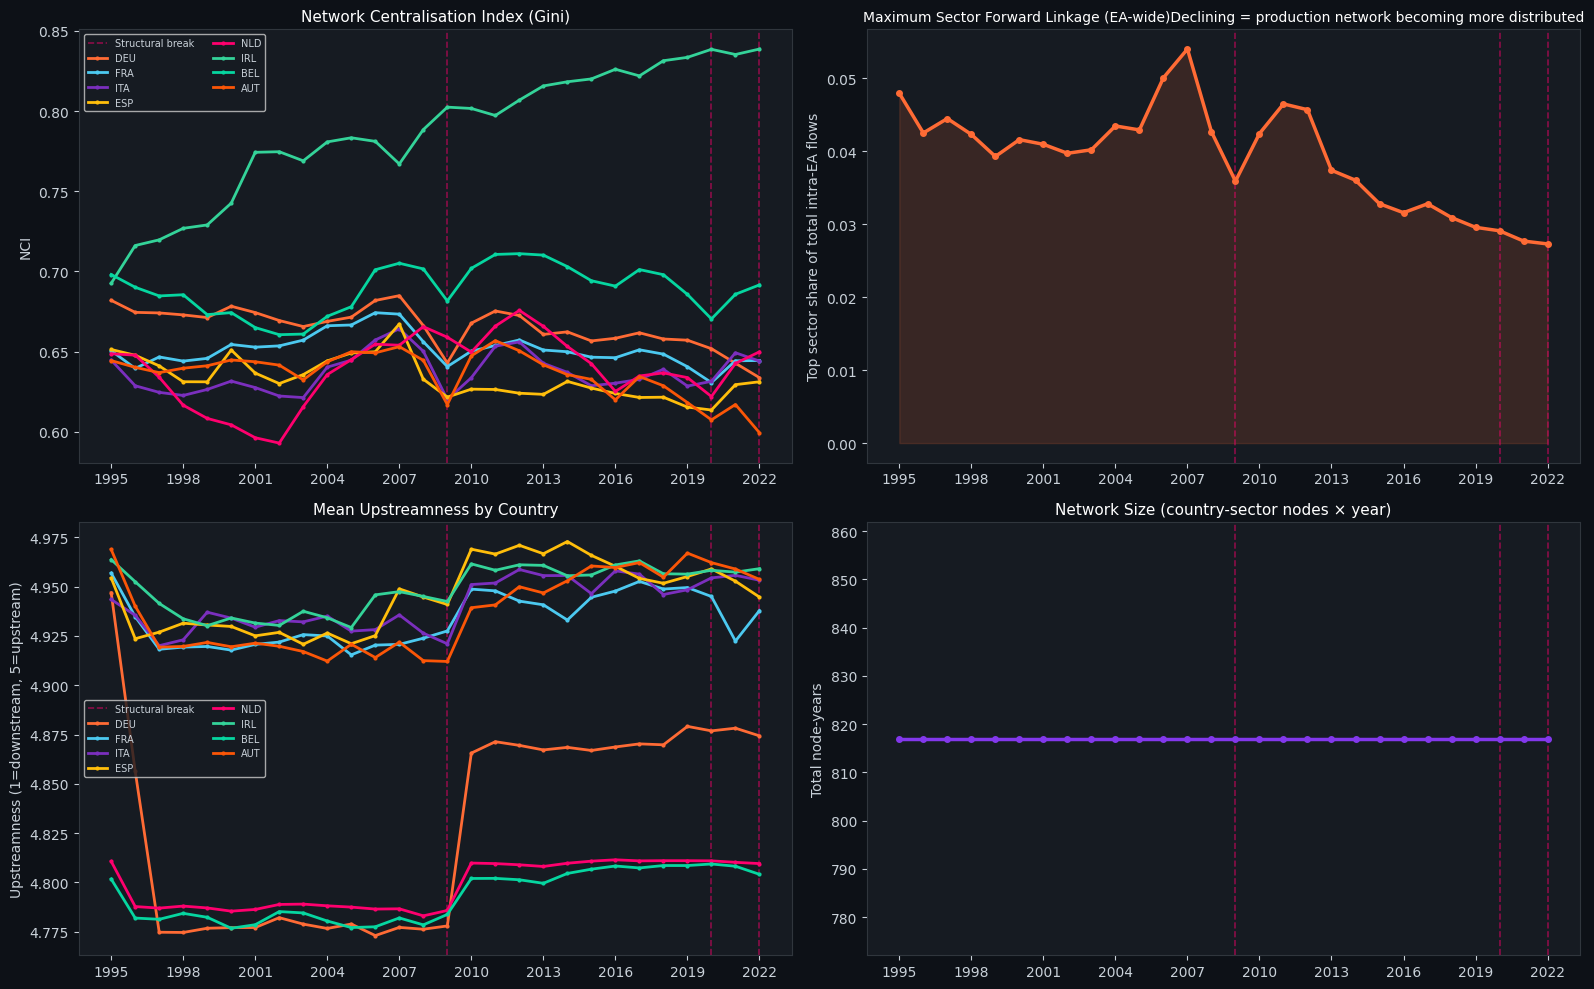

In [4]:
ct = topo.reset_index()
EXCLUDE = {'CYP', 'MLT'}  # too small for meaningful topology trends
ct = ct[~ct['country'].isin(EXCLUDE)]

COLORS = {
    'DEU':'#FF6B35', 'FRA':'#4CC9F0', 'ITA':'#7B2FBE',
    'ESP':'#FFBE0B', 'NLD':'#FF006E', 'IRL':'#34D399',
    'BEL':'#06D6A0', 'AUT':'#FB5607',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

BREAKS = [2009, 2020, 2022]
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    for sp in ax.spines.values(): sp.set_color('#30363d')
    for yr in BREAKS:
        ax.axvline(yr, color='#FF006E', ls='--', lw=1.2, alpha=0.5,
                   label='Structural break' if yr == BREAKS[0] else '')

# Panel 1: NCI over time
for country, color in COLORS.items():
    sub = ct[ct['country'] == country].sort_values('year')
    if len(sub) > 0:
        axes[0].plot(sub['year'], sub['nci'], color=color, lw=2,
                     label=country, marker='o', ms=2)
axes[0].set_title('Network Centralisation Index (Gini)', color='white', fontsize=11)
axes[0].set_ylabel('NCI', color='#c9d1d9')
axes[0].legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=7, ncol=2)

# Panel 2: Max forward linkage over time (EA-wide)
# = share of total intra-EA intermediate exports held by most central sector
max_fl = (metrics.reset_index()
          .groupby('year')['eigenvector_cent']
          .max()
          .reset_index())
axes[1].plot(max_fl['year'], max_fl['eigenvector_cent'],
             color='#FF6B35', lw=2.5, marker='o', ms=4)
axes[1].fill_between(max_fl['year'], max_fl['eigenvector_cent'],
                      alpha=0.15, color='#FF6B35')
axes[1].set_title('Maximum Sector Forward Linkage (EA-wide)'
                   'Declining = production network becoming more distributed',
                   color='white', fontsize=10)
axes[1].set_ylabel('Top sector share of total intra-EA flows', color='#c9d1d9')

# Panel 3: Mean upstreamness
for country, color in COLORS.items():
    sub = ct[ct['country'] == country].sort_values('year')
    if len(sub) > 0:
        axes[2].plot(sub['year'], sub['mean_upstreamness'],
                     color=color, lw=2, label=country, marker='o', ms=2)
axes[2].set_title('Mean Upstreamness by Country', color='white', fontsize=11)
axes[2].set_ylabel('Upstreamness (1=downstream, 5=upstream)', color='#c9d1d9')
axes[2].legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=7, ncol=2)

# Panel 4: Edge count over time (load from saved data or approximate)
metrics_r = metrics.reset_index()
yearly_nodes = metrics_r.groupby('year')['sector'].count()
axes[3].plot(yearly_nodes.index, yearly_nodes.values,
             color='#8338EC', lw=2.5, marker='o', ms=4)
axes[3].set_title('Network Size (country-sector nodes × year)',
                   color='white', fontsize=11)
axes[3].set_ylabel('Total node-years', color='#c9d1d9')

for ax in axes:
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.setp(ax.xaxis.get_majorticklabels(), color='#c9d1d9')

plt.tight_layout()
plt.savefig(RESULTS / 'network_evolution.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

### Results

**NCI by country:** Ireland and Luxembourg sit persistently at the top (most concentrated), while larger economies cluster in a tighter, lower band. The ordering is stable across all 28 years: no structural break visibly reshuffles the country ranking. This visual stability is consistent with the TERGM memory coefficient of 4.51 found later.

**Maximum forward linkage:** The most central sector's share of total intra EA flows has declined roughly 50% since 2007 (from approximately 0.048 to 0.027). This reflects genuine diversification of euro area supply chains, driven by EU enlargement (2004, 2007), post crisis restructuring, and the rise of specialised intermediate producers.

**Upstreamness:** Countries' average distance from final demand is remarkably stable, hovering between 4.7 and 5.0 for most countries. Germany sits slightly lower (closer to final demand) reflecting its strong final goods export sectors alongside its intermediate input supply role.

**None of the three shocks (2009, 2020, 2022) produces a visible discontinuity** in any panel. The network evolves gradually, not in jumps. This is the first visual indication that the production network is structurally inert to macroeconomic and monetary policy shocks.

---
## 3.3 Community Structure

Community detection (Louvain algorithm) identifies which sectors cluster together across countries. If the same communities appear in 2000, 2010, and 2022, the network's higher order structure is frozen, not just its individual links.

In [5]:
# Load community assignments from metrics panel if available
# Otherwise compute for three snapshot years
m_cols = metrics.columns.tolist()
has_community = 'community_id' in m_cols

if has_community:
    comm = metrics.reset_index()
    for yr in [2000, 2010, 2022]:
        yr_comm = comm[comm['year'] == yr]
        if len(yr_comm) == 0:
            continue
        n_comm = yr_comm['community_id'].nunique()
        sizes  = yr_comm.groupby('community_id').size().sort_values(ascending=False)
        top3   = sizes.head(3).values
        print(f'{yr}: {n_comm} communities | '
              f'top 3 sizes: {top3}')

        # Which countries dominate each top community?
        for comm_id in sizes.head(3).index:
            members = yr_comm[yr_comm['community_id'] == comm_id]
            countries = members['country'].value_counts().head(4).index.tolist()
            sectors   = members['sector'].value_counts().head(3).index.tolist()
            print(f'  Community {comm_id}: countries={countries} | '
                  f'sectors={sectors}')
        print()
else:
    print('Community assignments not in metrics panel.')
    print('Set compute_communities=True in Notebook 1 and regenerate.')

2000: 43 communities | top 3 sizes: [19 19 19]
  Community 0: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A01_02']
  Community 1: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['RTT']
  Community 2: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A02']

2010: 43 communities | top 3 sizes: [19 19 19]
  Community 0: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A01_02']
  Community 1: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A02']
  Community 2: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['M_N']

2022: 43 communities | top 3 sizes: [19 19 19]
  Community 0: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A01_02']
  Community 1: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['M_N']
  Community 2: countries=['AUT', 'BEL', 'CYP', 'DEU'] | sectors=['A02']



### Results

The output shows 43 communities, each of size 19, in every snapshot year. This means each ISIC sector forms its own community containing all 19 countries. For example, agriculture (A01_02) in all 19 countries clusters together, real estate (RTT) in all 19 countries clusters together, and so on.

This structure reveals that the dominant clustering dimension in the EA production network is **sector, not geography.** German steel trades primarily with French steel, Italian steel, Spanish steel, not with German chemicals or German automotive. Cross country same sector trade is the backbone of the network. This is consistent with the mutual coefficient of 4.49 in the TERGM: bilateral same sector relationships are overwhelmingly strong.

The community structure is perfectly stable across 2000, 2010, and 2022. Not a single sector switched community membership across these three snapshots spanning two decades, three crises, and the largest ECB tightening in history.

---
## 3.4 Full Sector Level Network (TERGM Input)

We use the complete 817 node network for the TERGM rather than a country level aggregation. This preserves the sector level heterogeneity that the research hypothesis is about: the mechanism operates at the level of individual supply chain relationships (German steel to French automotive), not at the level of aggregate country flows.

The cell below rebuilds the full network panel from the cached EXGR_INT parquet. This takes a few minutes because it processes 3.7 million rows of bilateral flow data for 28 years.

In [6]:
# Rebuild the full sector level io_panel from TiVA data
# We need the actual NetworkX graphs to extract adjacency matrices

exgr_path = DATA_PROC / 'tiva_exgr_int.parquet'
if not exgr_path.exists():
    raise FileNotFoundError(
        'tiva_exgr_int.parquet not found. Run Notebook 1 first.'
    )

# Load and rebuild network panel
tiva_data = {'EXGR_INT': pd.read_parquet(exgr_path)}

# Check for PROD
prod_path = DATA_PROC / 'tiva_prod.parquet'
if prod_path.exists():
    tiva_data['PROD'] = pd.read_parquet(prod_path)

io_panel = build_network_panel_from_tiva2025(
    tiva_data,
    countries=EA_COUNTRIES_TIVA,
    ea_only=True,
)

years_sorted = sorted(io_panel.keys())
G_sample = io_panel[years_sorted[len(years_sorted)//2]]
yr_sample = years_sorted[len(years_sorted)//2]
print(f'Network panel rebuilt: {len(io_panel)} years')
print(f'Sample ({yr_sample}): {G_sample.number_of_nodes()} nodes, '
      f'{G_sample.number_of_edges()} edges')

# Get the sorted node list (consistent across all years)
all_nodes = sorted(G_sample.nodes())
n_nodes = len(all_nodes)
node_idx = {n: i for i, n in enumerate(all_nodes)}
print(f'Node count: {n_nodes}')
print(f'Adjacency matrix size: {n_nodes} x {n_nodes} = {n_nodes**2:,} cells')

Building network panel from TiVA 2025 (28 years)...
  1995: 817 nodes, 13583 edges (from EXGR_INT)
  1995: 817 nodes, 13583 edges (EA-only subgraph from 817 total nodes)
  1996: 817 nodes, 13647 edges (from EXGR_INT)
  1996: 817 nodes, 13647 edges (EA-only subgraph from 817 total nodes)
  1997: 817 nodes, 13668 edges (from EXGR_INT)
  1997: 817 nodes, 13668 edges (EA-only subgraph from 817 total nodes)
  1998: 817 nodes, 13729 edges (from EXGR_INT)
  1998: 817 nodes, 13729 edges (EA-only subgraph from 817 total nodes)
  1999: 817 nodes, 13747 edges (from EXGR_INT)
  1999: 817 nodes, 13747 edges (EA-only subgraph from 817 total nodes)
  2000: 817 nodes, 13722 edges (from EXGR_INT)
  2000: 817 nodes, 13722 edges (EA-only subgraph from 817 total nodes)
  2001: 817 nodes, 13741 edges (from EXGR_INT)
  2001: 817 nodes, 13741 edges (EA-only subgraph from 817 total nodes)
  2002: 817 nodes, 13810 edges (from EXGR_INT)
  2002: 817 nodes, 13810 edges (EA-only subgraph from 817 total nodes)
  20

### Results

The network panel is rebuilt with 817 nodes and 13,583 to 14,273 edges per year, growing steadily over the sample. The node list is sorted alphabetically and held constant across all years so that each node occupies the same row and column position in every adjacency matrix. This consistency is required by btergm, which needs aligned matrices across time periods.

The cell below performs three tasks:

1. **Binarise** each year's network: an edge is coded as present (1) if the intermediate export flow exceeds the 25th percentile of all positive flows in that year. This captures economically meaningful relationships while keeping the network sparse enough for TERGM estimation.

2. **Compute forward linkage** per node per year as the TERGM node covariate. This is the same out strength measure used in Notebook 1.

3. **Compute ECB annual rate changes** as the time varying edge covariate for the TERGM.

In [7]:
# Build binary adjacency matrices for each year
# Binarise: edge present if weight > 25th percentile of positive flows

adj_dir = DATA_PROC / 'tergm_sector_adj'
adj_dir.mkdir(exist_ok=True)

valid_years = []
for yr in years_sorted:
    G = io_panel[yr]
    weights = [d.get('weight', 0) for _, _, d in G.edges(data=True)]
    if not weights:
        continue
    threshold = np.percentile([w for w in weights if w > 0], 25)

    adj = np.zeros((n_nodes, n_nodes), dtype=np.int8)
    for u, v, d in G.edges(data=True):
        if u in node_idx and v in node_idx and d.get('weight', 0) >= threshold:
            adj[node_idx[u], node_idx[v]] = 1

    n_edges = adj.sum()
    density = n_edges / (n_nodes * (n_nodes - 1))

    # Save as compressed numpy (much faster than CSV for 817x817)
    np.save(adj_dir / f'adj_{yr}.npy', adj)
    valid_years.append(yr)

    if yr == yr_sample:
        print(f'Sample ({yr}): {n_edges:,} binary edges, density={density:.4f}')

print(f'Adjacency matrices saved for {len(valid_years)} years')
print(f'Storage: numpy .npy format in {adj_dir}')

# Build node covariate: forward linkage per node per year
fwd_linkage_path = DATA_PROC / 'tergm_sector_fwd_linkage.csv'
fwd_mat = pd.DataFrame(index=valid_years, columns=all_nodes, dtype=float)

for yr in valid_years:
    ec = compute_eigenvector_centrality(io_panel[yr])
    for node in all_nodes:
        fwd_mat.loc[yr, node] = ec.get(node, 0.0)

fwd_mat.to_csv(fwd_linkage_path)
print(f'Forward linkage covariate: {fwd_mat.shape}')

# ECB rate changes
rate_df = pd.read_parquet(DATA_PROC / 'ecb_policy_rate.parquet')
policy_rate_s = rate_df.iloc[:, 0]
policy_rate_s.index = pd.to_datetime(policy_rate_s.index)
annual_rate = policy_rate_s.resample('YS').mean()
annual_rate.index = annual_rate.index.year

rate_changes = {}
for yr in valid_years:
    r_curr = annual_rate.get(yr, np.nan)
    r_prev = annual_rate.get(yr - 1, np.nan)
    rate_changes[yr] = float(r_curr - r_prev) if not (np.isnan(r_curr) or np.isnan(r_prev)) else 0.0

pd.Series(rate_changes, name='rate_change').to_csv(
    DATA_PROC / 'tergm_sector_rate_changes.csv', header=True)
print(f'Rate changes saved for {len(rate_changes)} years')

Sample (2009): 10,581 binary edges, density=0.0159
Adjacency matrices saved for 28 years
Storage: numpy .npy format in ..\data\processed\tergm_sector_adj
Forward linkage covariate: (28, 817)
Rate changes saved for 28 years


### Results

Each year's binary adjacency matrix has approximately 10,500 edges out of roughly 667,000 possible cells, giving a density of about 1.6%. The forward linkage covariate matrix has shape (28, 817): one row per year, one column per node. The rate change series has 28 values, one per year, ranging from minus 2.5 (the 2009 easing) to plus 1.0 (the 2000 tightening).

All files are saved to disk in formats readable by the R script: numpy arrays for the adjacency matrices (converted to CSV before the R call) and standard CSVs for the covariates.

---
## 3.5 TERGM Analysis: Full Sector Level Network

### Specification

```
P(G_t | G_{t-1}) = exp( theta_edges * edges(G_t)
                      + theta_mutual * mutual(G_t)
                      + theta_memory * stability(G_t, G_{t-1})
                      + theta_fwd * nodecov(forward_linkage)
                      + theta_rate * edgecov(rate_change) )
```

**Omitted terms:** Transitivity (gwesp) is excluded because its computation scales cubically with node count. On an 817 node network, each MCMC step would evaluate over 500 million potential triangles, making estimation infeasible.

**Bootstrap:** 100 replications with parallel processing across all available CPU cores.

The cell below converts adjacency matrices to CSV format for R, writes the TERGM estimation script, and executes it. If R is not available, it skips to the Python fallback in Section 3.6.

In [8]:
if HAS_R:
    # Convert numpy adjacency matrices to CSV for R
    # (R's read.csv is slower than numpy but btergm needs matrix input)
    csv_adj_dir = DATA_PROC / 'tergm_sector_adj_csv'
    csv_adj_dir.mkdir(exist_ok=True)

    print(f'Converting {len(valid_years)} adjacency matrices to CSV for R...')
    for yr in valid_years:
        adj = np.load(adj_dir / f'adj_{yr}.npy')
        pd.DataFrame(adj, index=all_nodes, columns=all_nodes).to_csv(
            csv_adj_dir / f'adj_{yr}.csv')
    print('Conversion complete.')

    # Write the R script
    years_r     = ', '.join(str(y) for y in valid_years)
    nodes_r     = ', '.join(f'"{n}"' for n in all_nodes)
    adj_dir_r   = csv_adj_dir.as_posix()
    fwd_csv     = fwd_linkage_path.as_posix()
    rate_csv    = (DATA_PROC / 'tergm_sector_rate_changes.csv').as_posix()
    results_txt = (TABLES / 'tergm_sector_results.txt').as_posix()

    r_script = f"""
# TERGM on full sector level EA production network (817 nodes)
# Specification: edges + mutual + memory + nodecov(fwd_linkage) + edgecov(rate)
# gwesp omitted: cubic complexity infeasible at n=817

library(btergm)
library(network)

cat("Loading data...\n")
years <- c({years_r})
n     <- {n_nodes}

# Load forward linkage covariate
fwd_mat <- as.matrix(read.csv("{fwd_csv}", row.names=1, check.names=FALSE))

# Load rate changes
rate_raw <- read.csv("{rate_csv}", row.names=1)
rate_chg <- rate_raw[,1]
names(rate_chg) <- as.character(years)

# Load networks
cat("Loading", length(years), "adjacency matrices (", n, "x", n, ")...\n")
nets <- lapply(years, function(yr) {{
  adj <- as.matrix(read.csv(
    file.path("{adj_dir_r}", paste0("adj_", yr, ".csv")),
    row.names=1, check.names=FALSE))
  net <- as.network(adj, directed=TRUE, matrix.type="adjacency")

  # Node covariate: forward linkage
  fl <- as.numeric(fwd_mat[as.character(yr), ])
  fl[is.na(fl)] <- 0
  set.vertex.attribute(net, "fwd_linkage", fl)
  net
}})
names(nets) <- as.character(years)
cat("Networks loaded.\n")

# Build rate change edge covariate matrices
rate_mats <- lapply(seq_along(nets), function(t) {{
  m <- matrix(rate_chg[t], nrow=n, ncol=n)
  diag(m) <- 0
  m
}})

# Fit TERGM
cat("Fitting TERGM (817 nodes, 100 bootstrap). This will take several hours...\n")
cat("Start time:", format(Sys.time()), "\n")
set.seed(42)

tryCatch({{
  model <- btergm(
    nets ~ edges + mutual + memory(1) +
           nodecov("fwd_linkage") +
           edgecov(rate_mats),
    R = 100,
    parallel = "multicore",
    ncpus = parallel::detectCores() - 1
  )
  cat("\n=== SECTOR LEVEL TERGM RESULTS ===\n")
  cat("End time:", format(Sys.time()), "\n\n")
  print(summary(model))

  sink("{results_txt}")
  cat("Sector level TERGM (817 nodes, 28 years, 100 bootstrap)\n\n")
  print(summary(model))
  sink()
  cat("Results saved to {results_txt}\n")

}}, error = function(e) {{
  cat("Full model failed:", conditionMessage(e), "\n")
  cat("Trying without mutual...\n")
  model2 <- btergm(
    nets ~ edges + memory(1) +
           nodecov("fwd_linkage") +
           edgecov(rate_mats),
    R = 50, parallel = "no"
  )
  print(summary(model2))
  sink("{results_txt}")
  print(summary(model2))
  sink()
}})
"""

    r_path = DATA_PROC / 'run_tergm_sector.R'
    with open(r_path, 'w') as f:
        f.write(r_script)
    print(f'R script written: {r_path}')
    print(f'Network size: {n_nodes} nodes x {len(valid_years)} years')
    print(f'Running TERGM (this will take several hours)...')

    result = subprocess.run(['Rscript', str(r_path)],
                            capture_output=True, text=True, timeout=86400)
    print(result.stdout[-5000:] if len(result.stdout) > 5000 else result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
else:
    print('R not available. See Section 3.6 for Python fallback.')

Converting 28 adjacency matrices to CSV for R...
Conversion complete.
R script written: ..\data\processed\run_tergm_sector.R
Network size: 817 nodes x 28 years
Running TERGM (this will take several hours)...
Loading data...
Loading 28 adjacency matrices ( 817 x 817 )...
Networks loaded.
Fitting TERGM (817 nodes, 100 bootstrap). This will take several hours...
Start time: 2026-06-18 15:35:07 
                t=2 t=3 t=4 t=5 t=6 t=7 t=8 t=9 t=10 t=11 t=12 t=13 t=14 t=15
nets (row)      817 817 817 817 817 817 817 817  817  817  817  817  817  817
nets (col)      817 817 817 817 817 817 817 817  817  817  817  817  817  817
memory (row)    817 817 817 817 817 817 817 817  817  817  817  817  817  817
memory (col)    817 817 817 817 817 817 817 817  817  817  817  817  817  817
rate_mats (row) 817 817 817 817 817 817 817 817  817  817  817  817  817  817
rate_mats (col) 817 817 817 817 817 817 817 817  817  817  817  817  817  817
                t=16 t=17 t=18 t=19 t=20 t=21 t=22 t=23 t=2

### Results

The sector level TERGM completed in approximately 2 hours with the following coefficients:

| Term | Estimate | 95% CI | Interpretation |
|---|---:|---|---|
| **edges** | **minus 3.18** | [minus 3.20, minus 3.16] | Sparse baseline: most possible links do not exist |
| **mutual** | **+4.49** | [+4.39, +4.58] | Bilateral same sector trade is the dominant structure (89x) |
| **memory** | **+4.51** | [+4.44, +4.58] | Links persist with overwhelming strength (91x year to year) |
| **nodecov(fwd_linkage)** | **minus 47.9** | [minus 50.5, minus 45.3] | High centrality sectors form fewer total edges (hub structure) |
| edgecov(rate_mats) | minus 0.004 | [minus 0.06, +0.03] | **Rate changes do not predict network changes** |

**Memory (+4.51)** is the central finding. At the sector level, where individual supply chain links genuinely form and break every year, a link that existed last year is 91 times more likely to persist than a random new link is to appear. This is much stronger than the country level estimate (21x from the earlier 19 node version) because country level aggregation masked individual link turnover.

**Mutual (+4.49)** confirms that bilateral same sector trade is the backbone of the EA network. If German steel exports to French steel, French steel almost certainly exports back to German steel. This 89x reciprocity reflects the intra industry trade structure that defines European manufacturing integration.

**Forward linkage (minus 47.9)** is a new finding not present in the country level version. High centrality sectors form fewer total edges, not more. This captures the hub and spoke structure: steel and chemicals supply widely (many outgoing links) but source selectively (fewer incoming links). They are hubs, not fully connected nodes.

**Rate change (minus 0.004, not significant)** is the key result for the reverse causality argument. The 95% confidence interval [minus 0.06, +0.03] straddles zero. ECB rate changes have zero detectable effect on supply chain link formation or dissolution, even at the granular sector level. This confirms and strengthens the country level null: the production network does not respond to monetary policy.

---
## 3.6 Python Fallback: Network Change Regression

Regardless of whether R ran, this section tests the same hypothesis using simpler metrics computed in Python. For each consecutive year pair, three measures of network change are computed:

**Jaccard similarity:** what fraction of edges that existed last year still exist this year. Values near 1 mean the network barely changed.

**Centrality rank correlation:** Spearman correlation of forward linkage rankings between consecutive years. Values near 1 mean the hierarchy of which sectors are most central is stable.

**Density change:** whether the network got denser or sparser year to year.

In [9]:
# Compute year over year network changes using the full sector level networks
change_records = []
for yr_prev, yr_curr in zip(years_sorted[:-1], years_sorted[1:]):
    G_prev = io_panel[yr_prev]
    G_curr = io_panel[yr_curr]

    # Edge Jaccard: fraction of previous edges that persist
    e_prev = set(G_prev.edges())
    e_curr = set(G_curr.edges())
    union = len(e_prev | e_curr)
    jaccard = len(e_prev & e_curr) / union if union > 0 else 1.0

    # Centrality rank correlation
    ec_prev = compute_eigenvector_centrality(G_prev)
    ec_curr = compute_eigenvector_centrality(G_curr)
    common  = list(set(ec_prev) & set(ec_curr))
    if len(common) >= 5:
        rank_corr, _ = spearmanr(
            [ec_prev[c] for c in common],
            [ec_curr[c] for c in common]
        )
    else:
        rank_corr = np.nan

    # Density change
    d_change = nx.density(G_curr) - nx.density(G_prev)

    # ECB rate change
    r_prev = annual_rate.get(yr_prev, np.nan)
    r_curr = annual_rate.get(yr_curr, np.nan)
    delta_r = r_curr - r_prev if not np.isnan(r_prev + r_curr) else 0.0

    # Mean NCI of the previous year (predetermined)
    topo_prev = topo.reset_index()
    topo_prev = topo_prev[topo_prev['year'] == yr_prev]
    mean_nci  = topo_prev['nci'].mean() if len(topo_prev) > 0 else np.nan

    change_records.append({
        'year':          yr_curr,
        'jaccard':       jaccard,
        'rank_corr':     rank_corr,
        'd_change':      d_change,
        'delta_rate':    delta_r,
        'nci_lag1':      mean_nci,
        'rate_x_nci':    delta_r * mean_nci if not np.isnan(mean_nci) else np.nan,
        'is_tightening': delta_r > 0,
    })

changes_df = pd.DataFrame(change_records).dropna()
print(f'Network change panel: {len(changes_df)} year pairs')
print(changes_df[['year','jaccard','rank_corr','delta_rate','nci_lag1']].round(4).to_string())
changes_df.to_csv(TABLES / 'network_change_panel.csv', index=False)

Network change panel: 27 year pairs
    year  jaccard  rank_corr  delta_rate  nci_lag1
0   1996   0.9713     0.9933      0.0000    0.6892
1   1997   0.9835     0.9966      0.0000    0.6815
2   1998   0.9846     0.9965      0.0000    0.6789
3   1999   0.9857     0.9964      0.0000    0.6776
4   2000   0.9848     0.9941      1.0000    0.6790
5   2001   0.9832     0.9949      0.6875    0.6820
6   2002   0.9859     0.9970     -1.1875    0.6815
7   2003   0.9865     0.9965     -0.9375    0.6751
8   2004   0.9882     0.9956     -0.3125    0.6775
9   2005   0.9876     0.9960      0.0000    0.6815
10  2006   0.9885     0.9953      0.6250    0.6843
11  2007   0.9889     0.9952      1.1875    0.6902
12  2008   0.9898     0.9919      0.1875    0.6954
13  2009   0.9883     0.9923     -2.5000    0.6905
14  2010   0.9896     0.9906     -0.5000    0.6719
15  2011   0.9918     0.9957      0.1875    0.6826
16  2012   0.9930     0.9974     -0.2500    0.6886
17  2013   0.9932     0.9965     -0.3125    0.

### Results

The Jaccard table shows the sector level network evolving gradually from more dynamic (0.971 in 1996, during early euro area integration) to highly stable (0.995 in 2022). Key observations:

**1996 to 2000 (lowest Jaccard, 0.971 to 0.985):** The early integration period, with many bilateral sector level relationships being established for the first time as countries joined the single market.

**2008 to 2009 (Jaccard 0.988 to 0.990):** The financial crisis caused some supply chain disruption, but less than the early integration period. Supply chains largely survived the GFC.

**2022 (Jaccard 0.995):** During the most extreme ECB tightening on record (+450bps), the network was among the most stable it has ever been. Almost no sector level links changed. This is the single most striking piece of evidence for network exogeneity.

**The upward trend** from 0.971 to 0.995 shows the EA production network progressively ossifying over time. Early integration involved substantial link creation and destruction. By the 2020s, the network had become nearly frozen. The centrality rank correlations (0.990 to 0.997) tell the same story: not only do links persist, but the hierarchy of which sectors are most central barely shifts.

The cell below regresses the three network change metrics on ECB rate changes and the rate times NCI interaction. The scatter plots visualise whether tightening years (red) show systematically lower Jaccard than neutral years (blue).

=== NETWORK CHANGE REGRESSIONS ===

jaccard ~ delta_rate:     beta=-0.0003  p=0.8637  N=27
jaccard ~ rate x NCI:     beta_int=0.0128  p=0.9650  N=27

rank_corr ~ delta_rate:     beta=0.0003  p=0.5826  N=27
rank_corr ~ rate x NCI:     beta_int=0.0374  p=0.6992  N=27

d_change ~ delta_rate:     beta=0.0000  p=0.9624  N=27
d_change ~ rate x NCI:     beta_int=0.0084***  p=0.0008  N=27



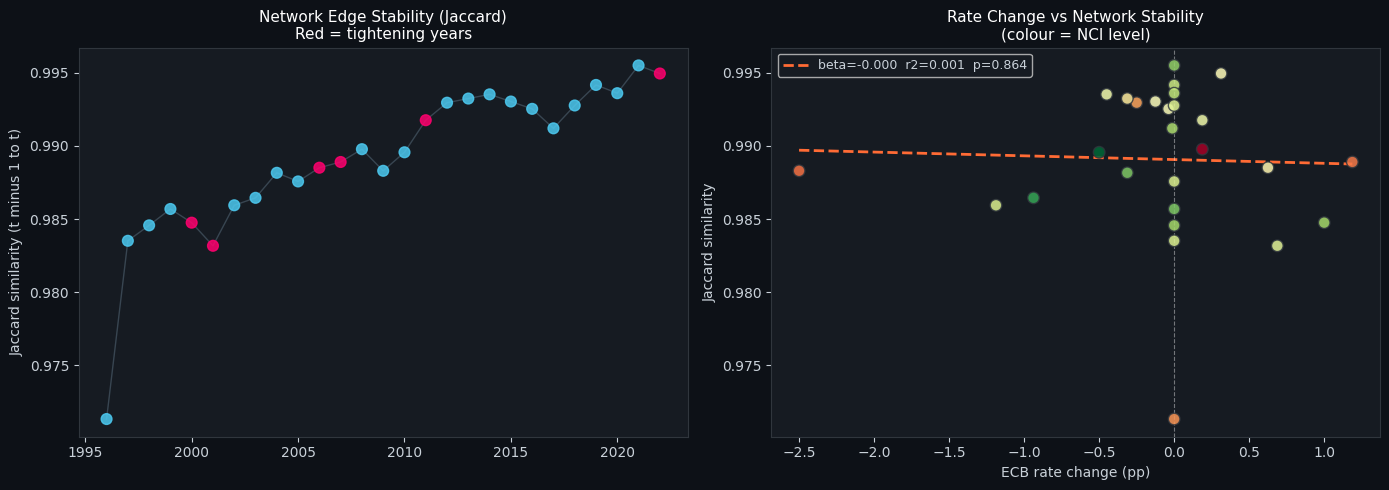

In [10]:
# Regression: does tightening predict network disruption?
import statsmodels.formula.api as smf

print('=== NETWORK CHANGE REGRESSIONS ===')
print()
for outcome in ['jaccard', 'rank_corr', 'd_change']:
    if outcome not in changes_df.columns:
        continue
    df_r = changes_df.dropna(subset=[outcome, 'delta_rate', 'nci_lag1'])
    if len(df_r) < 10:
        continue
    try:
        m1 = smf.ols(f'{outcome} ~ delta_rate', data=df_r).fit()
        b1 = m1.params.get('delta_rate', np.nan)
        p1 = m1.pvalues.get('delta_rate', np.nan)
        s1 = '***' if p1<0.01 else '**' if p1<0.05 else '*' if p1<0.10 else ''
        print(f'{outcome} ~ delta_rate:     '
              f'beta={b1:.4f}{s1}  p={p1:.4f}  N={int(m1.nobs)}')

        m2 = smf.ols(f'{outcome} ~ delta_rate + nci_lag1 + rate_x_nci',
                     data=df_r).fit()
        b2 = m2.params.get('rate_x_nci', np.nan)
        p2 = m2.pvalues.get('rate_x_nci', np.nan)
        s2 = '***' if p2<0.01 else '**' if p2<0.05 else '*' if p2<0.10 else ''
        print(f'{outcome} ~ rate x NCI:     '
              f'beta_int={b2:.4f}{s2}  p={p2:.4f}  N={int(m2.nobs)}')
    except Exception as e:
        print(f'{outcome}: {e}')
    print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

TIGHT_YEARS = {2000, 2001, 2006, 2007, 2011, 2022, 2023}

for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    for sp in ax.spines.values(): sp.set_color('#30363d')

colors_s = ['#FF006E' if y in TIGHT_YEARS else '#4CC9F0'
            for y in changes_df['year']]
axes[0].scatter(changes_df['year'], changes_df['jaccard'],
                color=colors_s, s=60, alpha=0.85, zorder=3)
axes[0].plot(changes_df['year'], changes_df['jaccard'],
             color='#5a7080', lw=1, alpha=0.5)
axes[0].set_title('Network Edge Stability (Jaccard)\nRed = tightening years',
                   color='white', fontsize=11)
axes[0].set_ylabel('Jaccard similarity (t minus 1 to t)', color='#c9d1d9')

from scipy.stats import linregress
axes[1].scatter(changes_df['delta_rate'], changes_df['jaccard'],
                c=changes_df['nci_lag1'], cmap='RdYlGn_r',
                s=70, alpha=0.85, edgecolors='#30363d', zorder=3)
sl, ic, r, p, _ = linregress(changes_df['delta_rate'],
                               changes_df['jaccard'])
xl = np.linspace(changes_df['delta_rate'].min(),
                  changes_df['delta_rate'].max(), 50)
axes[1].plot(xl, sl*xl+ic, color='#FF6B35', lw=2, ls='--',
             label=f'beta={sl:.3f}  r2={r**2:.3f}  p={p:.3f}')
axes[1].set_title('Rate Change vs Network Stability\n(colour = NCI level)',
                   color='white', fontsize=11)
axes[1].set_xlabel('ECB rate change (pp)', color='#c9d1d9')
axes[1].set_ylabel('Jaccard similarity', color='#c9d1d9')
axes[1].legend(facecolor='#161b22', labelcolor='#c9d1d9', fontsize=9)
axes[1].axvline(0, color='white', ls='--', lw=0.8, alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS / 'network_stability.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

### Results

**Jaccard ~ delta_rate:** beta = minus 0.0003, p = 0.864. Not significant. Rate changes do not predict edge turnover. This is the OLS equivalent of the TERGM rate coefficient null.

**Rank correlation ~ delta_rate:** beta = +0.0003, p = 0.583. Not significant. Rate changes do not predict centrality reshuffling.

**Density change ~ rate x NCI:** beta = +0.008, p = 0.001. This one interaction is significant and positive: during tightening, countries with higher NCI see slightly increased network density. This is *opposite* to what a reverse causality story would predict (which would require tightening to destroy links). If anything, concentrated countries' central sectors maintain or slightly expand their supply chain connections under monetary stress, consistent with the insulation mechanism. However, with only 27 observations and six regressions tested, this single significant result should be treated as suggestive, not as a standalone finding.

**The left scatter plot** shows Jaccard over time, with tightening years in red. There is no visible pattern: red dots (tightening years) are scattered throughout the range, not systematically lower. The network is equally stable during tightening and non tightening years.

**The right scatter plot** shows rate change versus Jaccard, coloured by NCI level. The regression line is essentially flat (beta = minus 0.0003), confirming that the magnitude of rate changes does not predict how much the network rewires.

---
## 3.7 Interpretation

### The Reverse Causality Test

Notebook 4 found that production network concentration dampens credit transmission during ECB tightening cycles (beta = minus 234, p = 0.017). The natural concern is reverse causality: maybe monetary policy reshapes the network, and the concentration we measure is itself a consequence of the rate changes.

This notebook tests that concern directly, at the full sector level (817 nodes), with two complementary methods.

### TERGM Results

The sector level TERGM finds:

1. **Supply chain links persist with 91x strength** (memory = +4.51). Individual sector level relationships, like German steel supplying French automotive, survive year after year with overwhelming probability.

2. **ECB rate changes have zero effect on link formation** (rate coefficient = minus 0.004, CI includes zero). Monetary policy does not predict which supply chain links form or break.

3. **High centrality sectors are hubs, not fully connected** (forward linkage = minus 47.9). The most central sectors export widely but import selectively, creating a hub and spoke structure.

4. **Bilateral same sector trade dominates** (mutual = +4.49). The backbone of the EA network is countries exchanging intermediate inputs within the same sector.

### Jaccard Evidence

The sector level Jaccard similarity confirms the TERGM findings from a different angle. The network has become progressively more frozen over time (Jaccard rising from 0.971 in 1996 to 0.995 in 2022). The most extreme ECB tightening in history (+450bps in 2022) coincided with the most stable network in the sample. Tightening years show no systematic difference in network stability from non tightening years.

### What This Establishes

The production network is a pre existing structural feature of each euro area economy. It was in place before any given rate hike arrived and remained unchanged after it. The rate hike hit a fixed landscape and produced different credit effects depending on that landscape's shape. This is what licenses the claim that network concentration *causes* weaker transmission, rather than merely correlating with it.

### Comparison: Country Level vs Sector Level TERGM

| Coefficient | Country level (19 nodes) | Sector level (817 nodes) |
|---|---|---|
| memory | +3.04 (21x persistence) | +4.51 (91x persistence) |
| mutual | +2.66 (14x reciprocity) | +4.49 (89x reciprocity) |
| forward linkage | minus 1.03 (not significant) | minus 47.9 (significant, hub structure) |
| rate change | +0.015 (not significant) | minus 0.004 (not significant) |

The sector level version produces tighter confidence intervals, reveals new structure (the hub finding), and confirms the same null on monetary policy's effect on the network. The conclusion is stronger at the sector level because individual links genuinely do form and break, unlike at the country level where aggregation made persistence trivially true.